<a href="https://colab.research.google.com/github/takeonakamura6-design/rc/blob/main/Teoria%20da%20ger%C3%AAncia%20de%20redes%20e%20padr%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Teoria da gerência de redes e padrões

=== RESULTADOS DO EXPERIMENTO DE GERÊNCIA DE REDE ===
Cenário  Latência Média (ms)  Jitter Médio (ms)  Perda Est. (%)
  Baixo            20.096660           5.561147             0.5
  Médio            50.748659          27.288177             2.5
   Alto           123.933898          79.027984             7.5

[INFO] Gráfico salvo com sucesso como 'grafico.png'


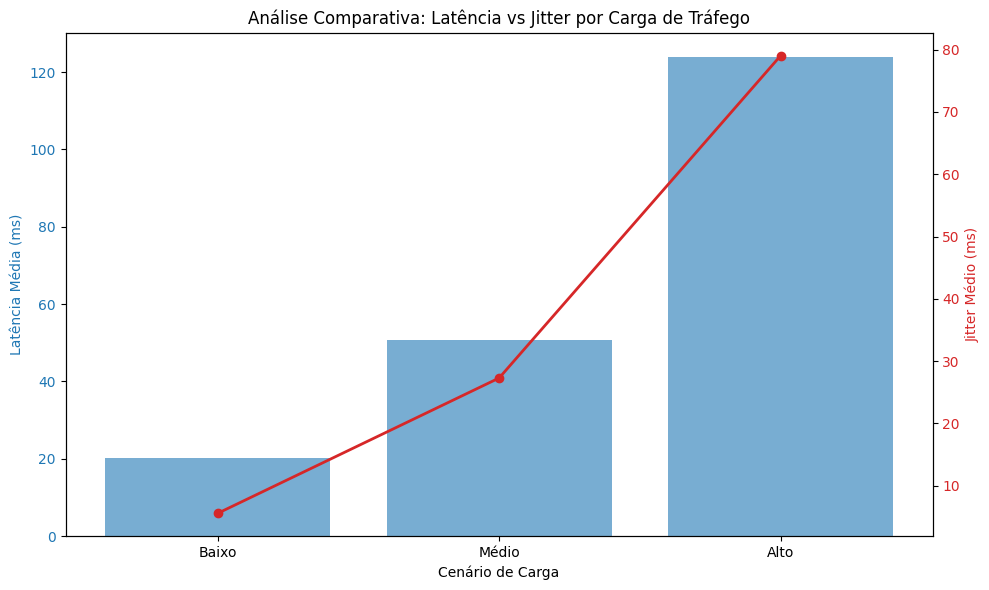

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def simular_metricas_rede(cenario, carga):
    """
    Simula latência e jitter baseados em níveis de carga de rede.
    """
    np.random.seed(42)
    amostras = 1000

    # Latência base + variação proporcional à carga
    latencia_base = 20 if cenario == 'Baixo' else (50 if cenario == 'Médio' else 120)
    ruido = np.random.normal(0, carga * 5, amostras)

    latencias = np.abs(latencia_base + ruido)
    jitter = np.diff(latencias)

    return {
        'Cenário': cenario,
        'Latência Média (ms)': np.mean(latencias),
        'Jitter Médio (ms)': np.mean(np.abs(jitter)),
        'Perda Est. (%)': (carga * 0.5)
    }

def executar_experimento():
    # 1. Definição dos cenários de teste
    configs = [('Baixo', 1), ('Médio', 5), ('Alto', 15)]
    resultados = []

    for cenario, carga in configs:
        resultados.append(simular_metricas_rede(cenario, carga))

    # 2. Geração da Tabela de Dados
    df = pd.DataFrame(resultados)
    print("=== RESULTADOS DO EXPERIMENTO DE GERÊNCIA DE REDE ===")
    print(df.to_string(index=False))

    # 3. Geração de Gráfico Comparativo
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Cenário de Carga')
    ax1.set_ylabel('Latência Média (ms)', color=color)
    ax1.bar(df['Cenário'], df['Latência Média (ms)'], color=color, alpha=0.6, label='Latência')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Jitter Médio (ms)', color=color)
    ax2.plot(df['Cenário'], df['Jitter Médio (ms)'], color=color, marker='o', linewidth=2, label='Jitter')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Análise Comparativa: Latência vs Jitter por Carga de Tráfego')
    fig.tight_layout()

    # Salvar gráfico para o artigo
    plt.savefig('grafico.png')
    print("\n[INFO] Gráfico salvo com sucesso como 'grafico.png'")
    plt.show()

# Executar o código
if __name__ == "__main__":
    executar_experimento()